# 🤖 LLM Examples - 1: Running OpenAI models in LangGraph

**Author:** *José Ignacio Orlando, PhD*

In this example we're going to learn how to integrate OpenAI's language models into LangGraph to create our first real AI-powered agent. 

This example builds upon the foundation we established in the previous LangGraph basics examples, but now we're adding the "brain" - an actual Large Language Model that can understand and respond to human input.

Our goal is to create a simple conversational agent that can interact with users through a chat interface, demonstrating how LangGraph can orchestrate LLM calls within a structured workflow.

## Step 1 - Set up the environment and LLM

Before we can use OpenAI's models, we need to set up our environment properly. This involves:

1. **Loading environment variables**: We use `python-dotenv` to load our API keys from a `.env` file, keeping sensitive information secure.
2. **Initializing the LLM**: We create an instance of `ChatOpenAI` from LangChain, which provides a standardized interface to OpenAI's models

The `load_dotenv()` function reads the `.env` file in your project directory, where you should store your OpenAI API key as `OPENAI_API_KEY=your_key_here`. This is a security best practice that prevents accidentally committing API keys to version control. Always remember to **not include .env files in your repository**. They should be part of your `.gitignore` file, to prevent leaking your API keys online.

In the example below we're using GPT-4o (oldy but goody), but you can easily switch to other models.

In [1]:
# import the dotenv library to load the API key from the .env file
from dotenv import load_dotenv 
# import the ChatOpenAI class from the langchain_openai module, that models interactions with OpenAI's models
from langchain_openai import ChatOpenAI

# load the API key from the .env file
load_dotenv()

# create an instance of the ChatOpenAI class
llm = ChatOpenAI(model="gpt-4o")


## Step 2 - Define the agent state

Now we need to define our agent state, which will hold the conversation history. Unlike our previous examples where we used simple strings, here we're working with LangChain's message system.

The `AgentState` uses a list of `HumanMessage` objects to store the conversation. This is important because:

- **Message history**: The LLM needs context from previous messages to maintain coherent conversations. It doesn't "remember" past conversations unless we pass them as input.
- **Structured format**: LangChain's message objects provide a standardized way to handle different types of messages (human, AI, system, etc.). LangChain includes internal "pieces of prompts" to make the model aware of what messages belonged to whom.
- **Extensibility**: This structure allows us to easily add system messages, tool calls, or other message types later.

In [2]:
# import the TypedDict class from the typing module, which is used to define the structure of our agent state 
from typing import TypedDict, List
# import the HumanMessage class from the langchain_core.messages module, which is used to store human messages
from langchain_core.messages import HumanMessage

# define the AgentState class, which is a TypedDict that contains a list of HumanMessage objects
class AgentState(TypedDict):
    messages: List[HumanMessage]

## Step 3 - Define the processing node

This is where the magic happens! Our `process` node is responsible for:

1. **Receiving the conversation state**: It gets the list of messages from the state
2. **Calling the LLM**: It passes the messages to the OpenAI model using `llm.invoke()`
3. **Handling the response**: It prints the AI's response and returns the updated state

The key difference from our previous examples is that this node actually communicates with an external AI service. The LLM processes all the messages in context and generates an appropriate response.

Notice that we're printing the response for user feedback, but we're not updating the state with the AI's response. This is intentional for this simple example - we're focusing on the basic interaction pattern. In any chatbot based application, you'd typically add the AI's response to the message history, and you keep that state updated so that the model takes that into consideration as context.

In [3]:
# define the process node, which is a function that takes an AgentState object and returns an AgentState object
def process(state: AgentState) -> AgentState:
    # call the LLM with the list of messages
    response = llm.invoke(state["messages"])
    # print the AI's response
    print(f"AI: {response.content}\n")
    return state

## Step 4 - Define the execution graph

Now we put everything together to create our conversational agent. The graph structure is simple:

1. **START** → `process`: When the conversation begins, we immediately process the user's input
2. `process` → **END**: After processing, the conversation cycle completes

This creates a linear flow where each user input triggers a complete processing cycle. The graph is intentionally simple because we're handling the conversation loop in our execution code rather than within the graph itself. But don't be frightened if the bot doesn't remember what you just said. We intentionally did that, and we're gonna correct it in the next examples.

The `compile()` method finalizes our agent and makes it ready for execution. This is where LangGraph optimizes the graph structure and prepares it for runtime.

In [4]:
# import the StateGraph class from the langgraph.graph module, which is used to define the structure of our graph
from langgraph.graph import StateGraph, START, END
# create a StateGraph object, which is a graph that contains a list of nodes and edges
graph = StateGraph(AgentState)

# add the edges
graph.add_edge(START, "process")
graph.add_node("process", process)
graph.add_edge("process", END) 

# compile the graph
agent = graph.compile()

Let's print the graph to see what happens:

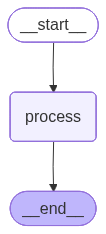

In [5]:
from IPython.display import Image, display
# retrieve the graph, draw the mermaing code, model that as an image, and display it
display(Image(agent.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

Notice that we're having a fully sequential execution, as we don't have loops nor conditional nodes. If we were implementing a fully functional chatbot, then we should have a conditional loop, keeping the conversation until the bot understand that you want to stop it.

## Step 5 - Execute the agent!

Time to bring our agent to life! This execution code creates an interactive chat loop where:

1. **User input**: We prompt the user to enter a message
2. **Agent processing**: We invoke our agent with the user's message
3. **Response display**: The agent processes the input and displays its response
4. **Loop continuation**: The process repeats until the user types "exit"

This demonstrates a fundamental pattern in conversational AI: the agent processes each message independently, maintaining context through the message history in the state.

Try having a conversation with your agent! Ask it questions, tell it stories, or just chat. Notice how it maintains context not throughout the whole conversation but just about your last message. That pattern is useful i.e. to orchestrate workflows, but not really for a chat interface.

**Note**: Each time you run this cell, you'll start a fresh conversation. The agent doesn't persist memory between different execution runs - that would require additional state management (which we'll explore in future examples).

In [6]:
# retrieve a user input (if you're in VSCode or Cursor, the text box is upwards!)
user_input = input("Enter: ")
# print the user's input
print("You: ", user_input)
# keep the conversation until the user types "exit"
while user_input != "exit":
    # invoke the agent with the user's message
    agent.invoke({"messages": [HumanMessage(content=user_input)]})
    # get a new user input
    user_input = input("Enter: ")
    # print the user's input
    print("You: ", user_input)

You:  Complete the sentence: "Soy / un perdedor / I'm a looser baby / So why don't ___"?
AI: the lyric continue with "you kill me" from the song "Loser" by Beck.

You:  Excellent!
AI: Thank you! How can I assist you today?

You:  What song was that one?
AI: Could you provide more details or context about the song you're referring to? For instance, lyrics, the artist, or the genre would help in identifying the song for you.

You:  exit
